# 00 · Setup & the synthetic ground truth

Welcome. This series takes apart four of the best gradient-boosting libraries -
**XGBoost, LightGBM, CatBoost** and **EBM** (Explainable Boosting Machine) - and
shows *how they work*, not just how to call them.

### The trick that makes this series work

We don't use a real dataset. We **generate** data where *we* define the true
signal, so afterward we can ask the sharp question:

> Did the model recover the signal we planted - and ignore the noise we added?

This notebook generates and visualises that ground truth.

In [17]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)

from utils import data as D
from utils import plotting as P


In [10]:
# Confirm every library imports and reports its version.
import sklearn, xgboost, lightgbm, catboost, interpret, shap
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("xgboost     ", xgboost.__version__)
print("lightgbm    ", lightgbm.__version__)
print("catboost    ", catboost.__version__)
print("interpret   ", interpret.__version__)
print("shap        ", shap.__version__)

numpy        2.4.6
pandas       3.0.3
scikit-learn 1.8.0
xgboost      3.3.0
lightgbm     4.6.0
catboost     1.2.10
interpret    0.7.8
shap         0.52.0


## The planted signal

The regression target is built as:

$$
y = \underbrace{3.0\,x_0 - 2.0\,x_1 + 1.5\,x_2}_{\text{linear main effects}}
  + \underbrace{2.5\,(x_3 \cdot x_4)}_{\text{interaction}}
  + \underbrace{2.0\,\sin(3 x_5)}_{\text{nonlinear}}
  + \underbrace{\text{effect}(\text{category})}_{\text{categorical}}
  + \varepsilon
$$

Features **x6, x7, x8** are pure noise - a good model should give them ~zero
importance. `category` is a string column (levels A-D) that CatBoost can ingest
natively.

In [ ]:
# 42 is a common seed, so try different seeds to test the  validity of the rest of the notebook.
X, y, gt = D.make_dataset(task="regression", n_samples=4000, seed=42)
print("X shape:", X.shape, "| dtypes include a categorical:", dict(X.dtypes.astype(str)))
X.head()

X shape: (4000, 10) | dtypes include a categorical: {'x0': 'float64', 'x1': 'float64', 'x2': 'float64', 'x3': 'float64', 'x4': 'float64', 'x5': 'float64', 'x6': 'float64', 'x7': 'float64', 'x8': 'float64', 'category': 'category'}


,x0,x1,x2,x3,x4,x5,x6,x7,x8,category
0,0.305,-1.040,0.750,0.941,-1.951,-1.302,0.128,-0.316,-0.017,B
1,-0.853,0.879,0.778,0.066,1.127,0.468,-0.859,0.369,-0.959,C
2,0.878,-0.050,-0.185,-0.681,1.223,-0.155,-0.428,-0.352,0.532,A
3,0.365,0.413,0.431,2.142,-0.406,-0.512,-0.814,0.616,1.129,B
4,-0.114,-0.840,-0.824,0.651,0.743,0.543,-0.666,0.232,0.117,B


In [12]:
# The ground-truth table - the answer key we'll grade models against.
gt.describe()

,feature,true_role,strength
0,x0,linear,3.0
1,x1,linear,-2.0
2,x2,linear,1.5
3,x3,interaction,2.5
4,x4,interaction,2.5
5,x5,nonlinear,2.0
6,x6,noise,0.0
7,x7,noise,0.0
8,x8,noise,0.0
9,category,categorical,5.5


## Visualising the structure

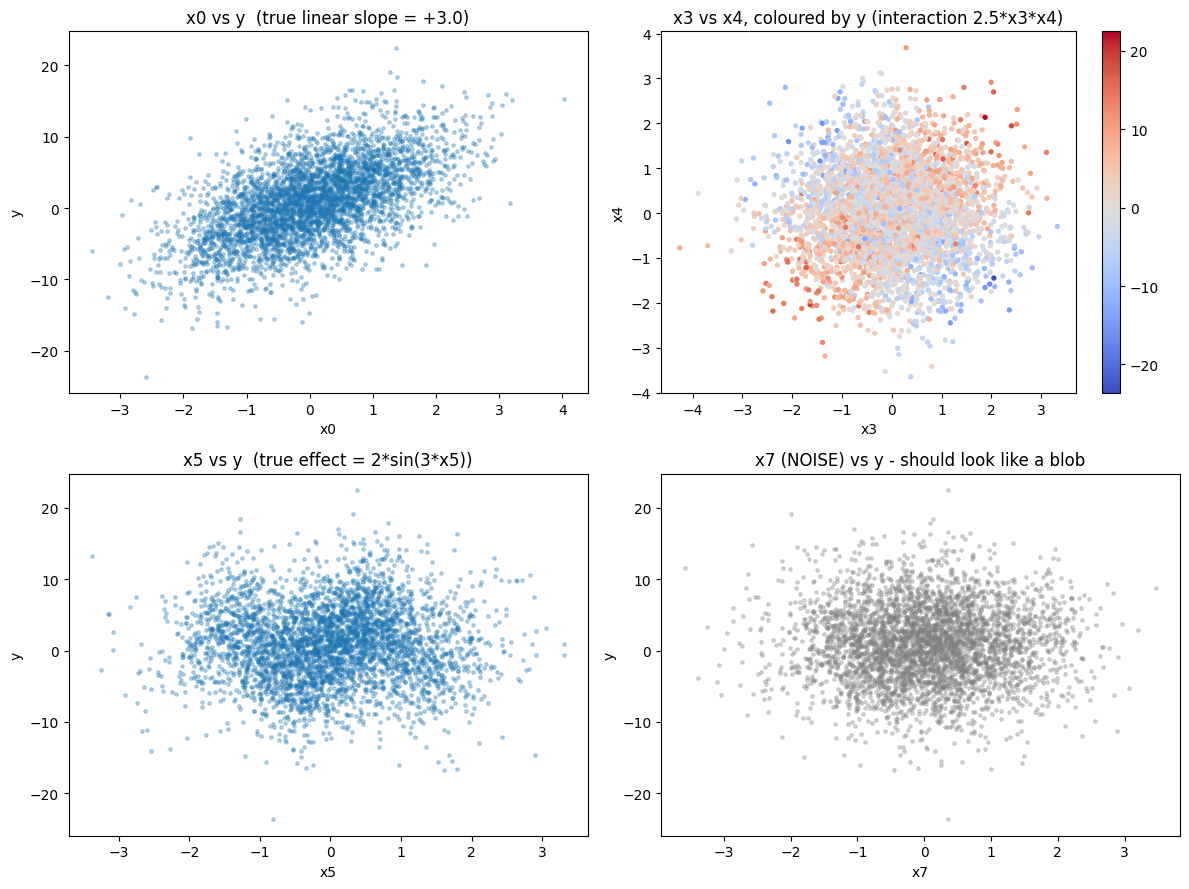

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Linear effect of x0 (true slope +3).
axes[0,0].scatter(X["x0"], y, s=6, alpha=0.3)
axes[0,0].set(title="x0 vs y  (true linear slope = +3.0)", xlabel="x0", ylabel="y")

# 2. The planted interaction: colour y by sign of x3*x4.
prod = X["x3"] * X["x4"]
sc = axes[0,1].scatter(X["x3"], X["x4"], c=y, s=8, cmap="coolwarm")
axes[0,1].set(title="x3 vs x4, coloured by y (interaction 2.5*x3*x4)",
              xlabel="x3", ylabel="x4")
plt.colorbar(sc, ax=axes[0,1])

# 3. The nonlinear sine effect of x5.
order = X["x5"].argsort()
axes[1,0].scatter(X["x5"], y, s=6, alpha=0.3)
axes[1,0].set(title="x5 vs y  (true effect = 2*sin(3*x5))", xlabel="x5", ylabel="y")

# 4. A pure-noise feature: no structure expected.
axes[1,1].scatter(X["x7"], y, s=6, alpha=0.3, color="grey")
axes[1,1].set(title="x7 (NOISE) vs y - should look like a blob",
              xlabel="x7", ylabel="y")
plt.tight_layout(); plt.show()

In [14]:
# Categorical effect: mean target per level vs the true planted effect.
import pandas as pd
summary = (pd.DataFrame({"category": X["category"], "y": y})
             .groupby("category", observed=True)["y"].mean()
             .rename("observed_mean").to_frame())
summary["true_effect"] = [gt.category_effects[c] for c in summary.index]
summary

,observed_mean,true_effect
category,,
A,3.041,3.0
B,-0.490,-1.0
C,0.357,0.5
D,-2.216,-2.5


## The classification variant

Same structured signal, passed through a logistic link and sampled to 0/1.

class balance: {1: 0.501, 0: 0.499}


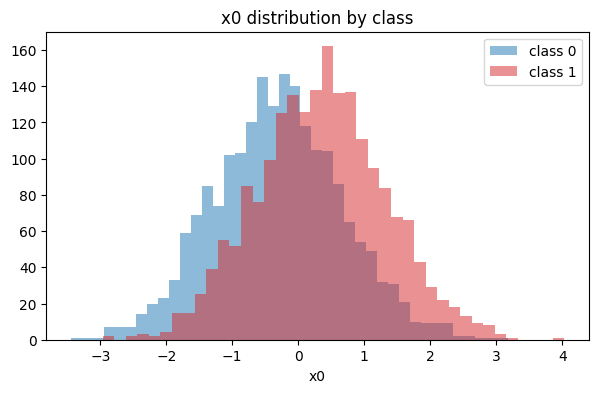

In [15]:
Xc, yc, gtc = D.make_dataset(task="classification", n_samples=4000, seed=42)
print("class balance:", yc.value_counts(normalize=True).round(3).to_dict())
# Separation along the strongest linear feature x0:
fig, ax = plt.subplots(figsize=(7,4))
for cls, color in [(0, "#1f77b4"), (1, "#d62728")]:
    ax.hist(Xc.loc[yc==cls, "x0"], bins=40, alpha=0.5, label=f"class {cls}", color=color)
ax.set(title="x0 distribution by class", xlabel="x0"); ax.legend(); plt.show()

In [16]:
# Cache both datasets so later notebooks load identical data.
os.makedirs("../data", exist_ok=True)
X.assign(target=y).to_parquet("../data/regression.parquet")
Xc.assign(target=yc).to_parquet("../data/classification.parquet")
print("saved ../data/regression.parquet and ../data/classification.parquet")

saved ../data/regression.parquet and ../data/classification.parquet


## Takeaways

- We have a **regression** and a **classification** dataset with an **answer key**.
- Planted effects: 3 linear, 1 interaction (x3·x4), 1 nonlinear (x5), 1 categorical.
- Planted distractors: noise features x6, x7, x8.

Next: **`01_boosting_from_scratch`** - build a tiny GBDT by hand to see the core
mechanic before we touch the real libraries.